# Procesamiento de dataset
---

## Objetivo

Desarrollar un modelo de aprendizaje automático que clasifique páginas web según problemas de accesibilidad, para promover la inclusión digital y detectar  barreras que afectan a personas con discapacidad.

## Funcionamiento

* **Entrada**: dataframe con todos los análisis de accesibilidad web registrados en el archivo 'universidades-taw.csv'
* **Proceso**: análisis exploratorio de datos, limpieza, preprocesamiento y modelado (modelos de machine learning supervisado para clasificación binaria). Evaluación del rendimiento de cada modelo y selección del modelo más adecuado.
* **Salida**: mejor modelo guardado en el archivo 'model.pkl'

## Características del dataset

* Conjuntos de datos de análisis de barreras de accesibilidad de las páginas web de las instituciones universitarias (universidades e institutos universitarios) de la República Argentina en 2025
* Número de instancias: 141
* Número de variables: 12 numericas, predictoras y la clase indica si la página presenta o no problemas de accesibilidad web

### Información de variables

| Variables               | Tipo       | Descripción                                                      |
| --                      | --         | --                                                               |
| **nombre**              | categórica | Nombre de la institución universitaria                           |
| **url**                 | categórica | Dirección de la página web de la institución                     |
| **doc_language_ok**     | numérica   | Cantidad de declaración del idioma del documento                 |
| **alt_texts_ok**        | numérica   | Cantidad de imágenes con texto alternativo                       |
| **input_labels_ok**     | numérica   | Cantidad de entradas de formulario con etiqueta                  |
| **empty_buttons_ok**    | numérica   | Cantidad de botones no vacíos                                    |
| **empty_links_ok**      | numérica   | Cantidad de enlaces no vacíos                                    |
| **color_contrast_ok**   | numérica   | Cantidad de texto con contraste medio o alto                     |
| **doc_language_fail**   | numérica   | Cantidad de idioma del documento faltante                        |
| **alt_texts_fail**      | numérica   | Cantidad de imágenes sin texto alternativo                       |
| **input_labels_fail**   | numérica   | Cantidad de entradas de formulario sin etiqueta                  |
| **empty_buttons_fail**  | numérica   | Cantidad de botones vacíos                                       |
| **empty_links_fail**    | numérica   | Cantidad de enlaces vacíos                                       |
| **color_contrast_fail** | numérica   | Cantidad de texto con bajo contraste                             |
| **ratio**               | numérica   | Nivel de accesibilidad real alcanzado en la prueba (éxito/total) |
| **clase**               | categórica | "sin_prob_aw" si ratio alcanza el valor mínimo deseado (0.75)    |

### Clase

* **sin_prob_aw**
* **con_prob_aw**

## Importación de librerias

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

## Carga de datos

In [102]:
# carga datos desde un archivo CSV
df = pd.read_csv('universidades-taw.csv', sep=';')

## Exploración de datos

In [103]:
# muestra las primeras 5 filas
df.head()

,nombre,url,doc_language_ok,alt_texts_ok,input_labels_ok,empty_buttons_ok,empty_links_ok,color_contrast_ok,doc_language_fail,alt_texts_fail,input_labels_fail,empty_buttons_fail,empty_links_fail,color_contrast_fail,ratio,clase
0,Instituto Universitario de Gendarmería Nacional,https://iugna.edu.ar,1,6,0,7,15,41,0,5,0,0,3,8,0.813953,sin_prob_aw
1,Instituto Universitario de la Policía Federal ...,https://www.iupfa.edu.ar,0,17,0,0,93,17,1,11,0,0,11,73,0.569507,con_prob_aw
2,Instituto Universitario de Seguridad Marítima,https://iusm.edu.ar,1,4,0,1,26,47,0,3,0,0,1,4,0.908046,sin_prob_aw
3,Universidad Autónoma de Entre Ríos,https://www.uader.edu.ar/,1,3,1,13,115,125,0,54,0,3,30,68,0.624697,con_prob_aw
4,Universidad de Buenos Aires,https://www.uba.ar/,1,3,1,4,140,136,0,4,0,1,8,27,0.876923,sin_prob_aw


In [104]:
# lista los nombres de las columnas
df.columns

Index(['nombre', 'url', 'doc_language_ok', 'alt_texts_ok', 'input_labels_ok',
       'empty_buttons_ok', 'empty_links_ok', 'color_contrast_ok',
       'doc_language_fail', 'alt_texts_fail', 'input_labels_fail',
       'empty_buttons_fail', 'empty_links_fail', 'color_contrast_fail',
       'ratio', 'clase'],
      dtype='object')

In [105]:
# muestra cantidad de filas y columnas
df.shape

(141, 16)

In [106]:
# muestra información general del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   nombre               141 non-null    object 
 1   url                  141 non-null    object 
 2   doc_language_ok      141 non-null    int64  
 3   alt_texts_ok         141 non-null    int64  
 4   input_labels_ok      141 non-null    int64  
 5   empty_buttons_ok     141 non-null    int64  
 6   empty_links_ok       141 non-null    int64  
 7   color_contrast_ok    141 non-null    int64  
 8   doc_language_fail    141 non-null    int64  
 9   alt_texts_fail       141 non-null    int64  
 10  input_labels_fail    141 non-null    int64  
 11  empty_buttons_fail   141 non-null    int64  
 12  empty_links_fail     141 non-null    int64  
 13  color_contrast_fail  141 non-null    int64  
 14  ratio                141 non-null    float64
 15  clase                141 non-null    obj

* Se observa 141 filas (observaciones) y 16 columnas (variables).
* Se observa que las variables nombre, url y clase son de tipo object (variables categóricas), ratio de tipo float (variable numérica continua y el resto son de tipo int (variables numéricas discretas).
* Se observa que no hay observaciones faltantes, ya que todas las variables tienen el mismo número de observaciones que son 141.
* Uso de memoria: ~17.8 KB (muy liviano, nada preocupante).

In [107]:
# valores nulos por columna
df.isnull().sum()

nombre                 0
url                    0
doc_language_ok        0
alt_texts_ok           0
input_labels_ok        0
empty_buttons_ok       0
empty_links_ok         0
color_contrast_ok      0
doc_language_fail      0
alt_texts_fail         0
input_labels_fail      0
empty_buttons_fail     0
empty_links_fail       0
color_contrast_fail    0
ratio                  0
clase                  0
dtype: int64

In [108]:
# resumen estadístico de las variables (estadística descriptiva)
df.describe()

,doc_language_ok,alt_texts_ok,input_labels_ok,empty_buttons_ok,empty_links_ok,color_contrast_ok,doc_language_fail,alt_texts_fail,input_labels_fail,empty_buttons_fail,empty_links_fail,color_contrast_fail,ratio
count,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000
mean,0.943262,16.517730,1.574468,3.737589,168.468085,182.368794,0.056738,14.574468,1.609929,1.361702,9.170213,53.588652,0.809147
std,0.232165,20.674899,7.500699,4.745894,124.698525,172.230842,0.232165,17.707639,2.782016,3.019642,9.839394,82.355941,0.150131
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,0.000000,0.000000,94.000000,79.000000,0.000000,2.000000,0.000000,0.000000,2.000000,10.000000,0.744986
50%,1.000000,9.000000,0.000000,2.000000,148.000000,143.000000,0.000000,9.000000,1.000000,0.000000,6.000000,28.000000,0.849057
75%,1.000000,22.000000,1.000000,6.000000,213.000000,227.000000,0.000000,20.000000,2.000000,1.000000,13.000000,55.000000,0.908795
max,1.000000,134.000000,87.000000,27.000000,779.000000,1029.000000,1.000000,125.000000,15.000000,20.000000,45.000000,542.000000,1.000000


In [109]:
# cantidad de páginas con y sin problemas de accesibilidad web presentes en el dataset 
# para saber si los datos están o no balanceados
df['clase'].value_counts()

clase
sin_prob_aw    103
con_prob_aw     38
Name: count, dtype: int64

Entonces, hay 103 páginas que no presentan barreras de accesibilidad web, denotados como "sin_prob_aw", y 38 páginas que presentan barreras de accesibilidad web, denotados como "con_prob_aw". Por lo tanto, se tiene un problema de clasificación binaria

## Preparación de los datos

In [110]:
# eliminación de columnas irrelevantes, ya que no aportan información útil para el análisis o modelo
# generando ruido o confusión en el modelo, afectando su rendimiento
df = df.drop(columns=['nombre', 'url', 'ratio'])

In [111]:
# verficación de filas duplicadas
df.duplicated().sum()

3

In [112]:
# eliminación de filas duplicadas
df = df.drop_duplicates()

In [113]:
# separar variables explicativas y variable objetivo
X = df.drop(columns=['clase'])
y = df['clase']

In [114]:
# dataset con variables explicativas
X.head()

,doc_language_ok,alt_texts_ok,input_labels_ok,empty_buttons_ok,empty_links_ok,color_contrast_ok,doc_language_fail,alt_texts_fail,input_labels_fail,empty_buttons_fail,empty_links_fail,color_contrast_fail
0,1,6,0,7,15,41,0,5,0,0,3,8
1,0,17,0,0,93,17,1,11,0,0,11,73
2,1,4,0,1,26,47,0,3,0,0,1,4
3,1,3,1,13,115,125,0,54,0,3,30,68
4,1,3,1,4,140,136,0,4,0,1,8,27


In [115]:
# matriz de correlación
X.corr()

,doc_language_ok,alt_texts_ok,input_labels_ok,empty_buttons_ok,empty_links_ok,color_contrast_ok,doc_language_fail,alt_texts_fail,input_labels_fail,empty_buttons_fail,empty_links_fail,color_contrast_fail
doc_language_ok,1.000000,0.088497,0.024103,0.186478,0.151195,0.126449,-1.000000,0.017745,0.035092,-0.049758,0.078840,0.030432
alt_texts_ok,0.088497,1.000000,0.007998,0.267420,0.356278,0.389494,-0.088497,-0.241583,0.215769,0.051694,-0.004702,0.093375
input_labels_ok,0.024103,0.007998,1.000000,0.095247,0.010668,0.073508,-0.024103,-0.049431,-0.021715,0.018382,-0.096204,-0.049818
empty_buttons_ok,0.186478,0.267420,0.095247,1.000000,0.192407,0.239377,-0.186478,-0.106112,0.195245,0.035601,0.024295,0.059246
empty_links_ok,0.151195,0.356278,0.010668,0.192407,1.000000,0.494137,-0.151195,0.113826,0.084374,0.097424,0.115462,0.465183
color_contrast_ok,0.126449,0.389494,0.073508,0.239377,0.494137,1.000000,-0.126449,0.022898,0.318795,0.116430,0.021062,0.347030
doc_language_fail,-1.000000,-0.088497,-0.024103,-0.186478,-0.151195,-0.126449,1.000000,-0.017745,-0.035092,0.049758,-0.078840,-0.030432
alt_texts_fail,0.017745,-0.241583,-0.049431,-0.106112,0.113826,0.022898,-0.017745,1.000000,-0.007672,0.261798,0.310327,0.015321
input_labels_fail,0.035092,0.215769,-0.021715,0.195245,0.084374,0.318795,-0.035092,-0.007672,1.000000,0.081403,0.030967,0.351398
empty_buttons_fail,-0.049758,0.051694,0.018382,0.035601,0.097424,0.116430,0.049758,0.261798,0.081403,1.000000,0.001957,-0.004127


* No se observan variables correlacionadas

In [116]:
# dataset con variable objetivo
y.head()

0    sin_prob_aw
1    con_prob_aw
2    sin_prob_aw
3    con_prob_aw
4    sin_prob_aw
Name: clase, dtype: object

## División en train y test (70% / 30%)

In [117]:
# dividir en 70% entrenamiento y 30% prueba
# stratify: garantiza que los conjuntos train y test tengan la misma proporción de clases (o etiquetas) que el conjunto de datos original
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [118]:
# Cantidad de muestras para entrenamiento
X_train.shape[0]

96

In [119]:
# Cantidad de muestras para prueba
X_test.shape[0]

42

In [120]:
# Distribución de categorías dataset original, normalize=True da proporciones
y.value_counts(normalize=True)

clase
sin_prob_aw    0.724638
con_prob_aw    0.275362
Name: proportion, dtype: float64

In [121]:
# Distribución de categorías dataset entrenamiento
y_train.value_counts(normalize=True)

clase
sin_prob_aw    0.729167
con_prob_aw    0.270833
Name: proportion, dtype: float64

In [122]:
# Distribución de categorías dataset prueba
y_test.value_counts(normalize=True)

clase
sin_prob_aw    0.714286
con_prob_aw    0.285714
Name: proportion, dtype: float64

## Inicialización de modelos

In [123]:
models = {}

# Logistic Regression
models['Logistic Regression'] = LogisticRegression(max_iter=1000)

# Support Vector Machines
# SVM con probabilidades habilitadas
models['Support Vector Machines'] = SVC(probability=True)

# Decision Trees
models['Decision Trees'] = DecisionTreeClassifier()

# Random Forest
models['Random Forest'] = RandomForestClassifier()

# Naive Bayes
models['Naive Bayes'] = GaussianNB()

# K-Nearest Neighbors
models['K-Nearest Neighbor'] = KNeighborsClassifier()

## Evaluación del rendimiento de cada modelo

In [130]:
roc_auc, accuracy, precision, recall, f1 = {}, {}, {}, {}, {}
predictions = {}

for key in models.keys():
    
    # Entrenar el modelo con datos de train
    models[key].fit(X_train, y_train)
    
    # Hacer predicciones con datos de test
    predictions[key] = models[key].predict(X_test)
    
    # Calcular métricas

    if hasattr(models[key], "predict_proba"):          # cualquier modelo que implemente predict_proba
        # Obtener probabilidades de la clase positiva
        y_proba = models[key].predict_proba(X_test)[:, 1]
        roc_auc[key] = roc_auc_score(y_test.map({"sin_prob_aw":1, "con_prob_aw":0}), y_proba)
    elif hasattr(models[key], "decision_function"): 
        y_proba = models[key].decision_function(X_test)
        roc_auc[key] = roc_auc_score(y_test.map({"sin_prob_aw":1, "con_prob_aw":0}), y_proba)
    else:
        roc_auc[key] = None
 
    # Accuracy (exactitud): proporción de aciertos totales (predicciones correctas)
    # Accuracy = cant de decisiones correctas / cant total de casos
    # Accurary = (VP + VN) / total
    accuracy[key] = accuracy_score(y_test, predictions[key])

    # weighted: promedio ponderado según el soporte (cantidad de ejemplos por clase)
    # Precision: de las predicciones positivas, cuántas fueron correctas
    # Precisión = VP / (VP + FP)
    precision[key] = precision_score(y_test, predictions[key], average='weighted')

    # Recall (sensibilidad): de los casos positivos reales, cuántos detectó el modelo
    # Recall = VP / (VP + FN)
    recall[key] = recall_score(y_test, predictions[key], average='weighted')

    # F1-score: balance (media armónica) entre Precision y Recall
    # F1-score = 2 * ((Accuracy * Recall) / (Accuracy + Recall))
    # Se busca un F1 cercano a 1
    f1[key] = f1_score(y_test, predictions[key], average='weighted')

In [131]:
df_model = pd.DataFrame(index=models.keys(), columns=['ROC AUC', 'Accuracy', 'Precision', 'Recall'])
df_model['ROC AUC'] = roc_auc.values()
df_model['Accuracy'] = accuracy.values()
df_model['Precision'] = precision.values()
df_model['Recall'] = recall.values()
df_model['F1'] = f1.values()
df_model = df_model.sort_values(by='Accuracy', ascending=False)
df_model

,ROC AUC,Accuracy,Precision,Recall,F1
Logistic Regression,1.000000,0.976190,0.976959,0.976190,0.975868
K-Nearest Neighbor,0.894444,0.809524,0.813492,0.809524,0.786436
Random Forest,0.873611,0.785714,0.774892,0.785714,0.775510
Support Vector Machines,0.911111,0.761905,0.759398,0.761905,0.716387
Decision Trees,0.708333,0.761905,0.761905,0.761905,0.761905
Naive Bayes,0.794444,0.761905,0.761905,0.761905,0.761905


* El modelo elegido, para la necesidad a resolver, es el modelo **Logistic Regression** con una Exactitud del 97.61%

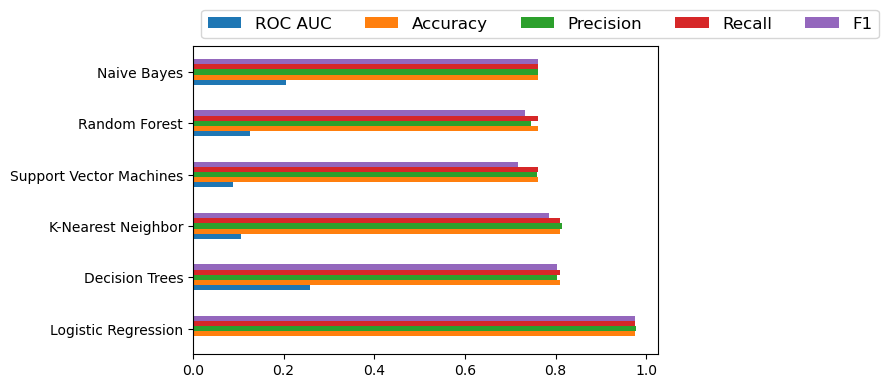

In [126]:
ax = df_model.plot.barh(figsize=(6, 4)) # ajuste del tamaño 
ax.legend( ncol=len(models.keys()),     # número de columnas en la leyenda 
           bbox_to_anchor=(0, 1),       # ancla la leyenda arriba del gráfico 
           loc='lower left',            # posición relativa 
           prop={'size': 12}            # tamaño de fuente de la leyenda 
)

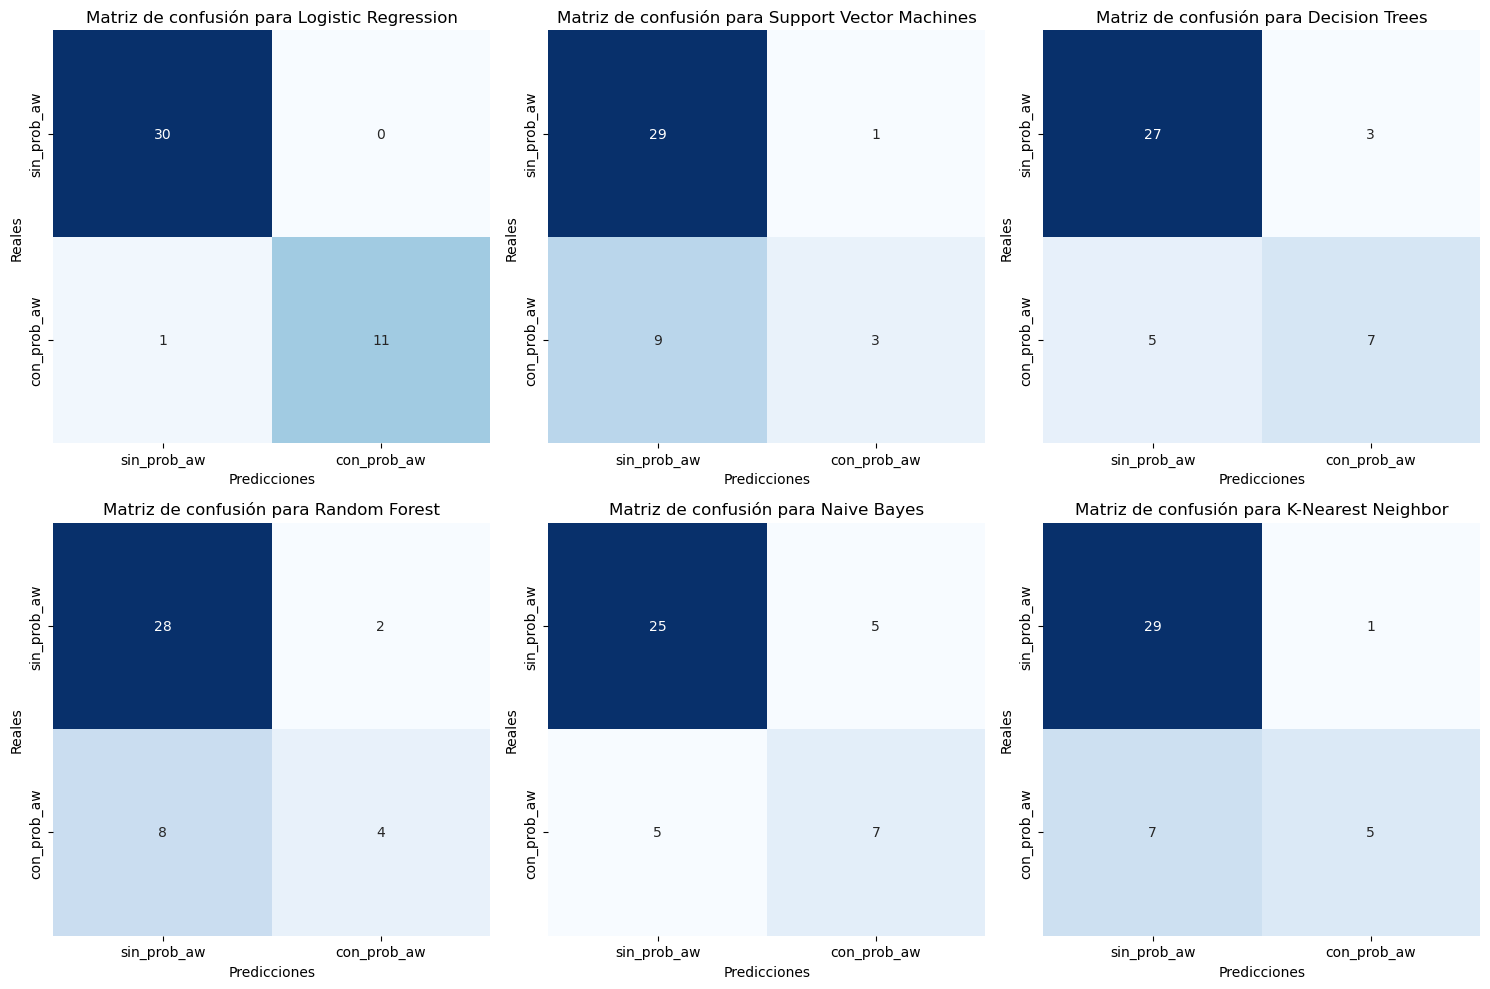

In [127]:
# Matriz de confusión para cada modelo
# Son métricas de evaluación para analizar la capacidad de clasificación de clases de los modelos construidos

# Crea la grilla de 2 filas x 3 columnas 
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Iterar sobre los modelos y los subplots 
for i, (key, ax) in enumerate(zip(models.keys(), axes.flat)): 
    cm = confusion_matrix(y_test, predictions[key], labels=["sin_prob_aw", "con_prob_aw"]) 
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["sin_prob_aw", "con_prob_aw"], yticklabels=["sin_prob_aw", "con_prob_aw"], ax=ax, cbar=False) 
    ax.set_xlabel("Predicciones") 
    ax.set_ylabel("Reales") 
    ax.set_title("Matriz de confusión para " + key)

plt.tight_layout() 
plt.show()

## Guardar mejor modelo

In [128]:
nombre_mejor_modelo = df_model.index[0]

In [129]:
with open("model.pkl", "wb") as f:
    pickle.dump(models[nombre_mejor_modelo], f)

---